<a href="https://colab.research.google.com/github/IvKorolev/Ml_hw/blob/main/Generate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#Скачиваем датасет
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz

!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-04-22 12:57:54--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   125KB/s    in 3m 17s  

2026-04-22 13:01:12 (121 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



In [13]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

In [16]:
data_dir = 'petfaces'
filepaths = []
breeds = []
species =[]

for folder_name in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder_name)

    if os.path.isdir(folder_path):
        parts = folder_name.split('_', 1)
        if len(parts) == 2:
            specie = parts[0]
            breed = parts[1]
        else:
            continue

        for file_name in os.listdir(folder_path):
            if file_name.endswith('.jpg'):
                filepaths.append(os.path.join(folder_path, file_name))
                breeds.append(breed)
                species.append(specie)

df = pd.DataFrame({
    'filepath': filepaths,
    'species': species,
    'breed': breeds
})

print(f"Всего изображений найдено: {len(df)}")

Всего изображений найдено: 3211


Пересядем на видюху

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


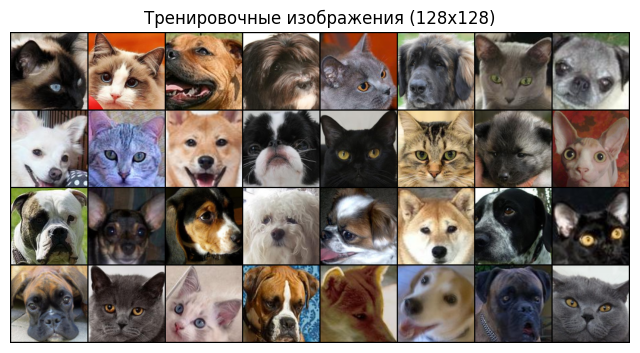

In [19]:
image_size = 128
batch_size = 64

# Трансформсы
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class PetFacesDataset(Dataset):
    def __init__(self, filepaths, transform=None):
        self.filepaths = filepaths
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert("RGB") # Защита от ч/б фото
        if self.transform:
            image = self.transform(image)
        return image

# Создаем Dataset и DataLoader
paths_list = df['filepath'].tolist()
dataset = PetFacesDataset(filepaths=paths_list, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Покажем один батч (проверка, что всё работает)
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Тренировочные изображения (128x128)")
plt.imshow(np.transpose(vutils.make_grid(real_batch[:32], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

# Обучаем GAN

In [20]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [25]:
nz = 100
ngf = 64
ndf = 64
nc = 3

class Generator128(nn.Module):
    def __init__(self):
        super(Generator128, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# ДИСКРИМИНАТОР: Добавили nn.Dropout(0.3) после каждого слоя активации!
class Discriminator128(nn.Module):
    def __init__(self):
        super(Discriminator128, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [23]:
netG = Generator128().to(device)
netG.apply(weights_init)

netD = Discriminator128().to(device)
netD.apply(weights_init)

print("Модели 128x128 созданы и инициализированы!")

Модели 128x128 созданы и инициализированы!


Начинаем обучение GAN со сглаживанием меток (Label Smoothing)...
[1/50][0/51] Loss_D: 2.8757 Loss_G: 48.9509
[1/50][25/51] Loss_D: 0.4642 Loss_G: 41.8204
[1/50][50/51] Loss_D: 0.3531 Loss_G: 40.8524
[2/50][0/51] Loss_D: 0.3918 Loss_G: 40.7196
[2/50][25/51] Loss_D: 0.3679 Loss_G: 40.0098
[2/50][50/51] Loss_D: 0.3411 Loss_G: 37.9694
[3/50][0/51] Loss_D: 0.3787 Loss_G: 36.9078
[3/50][25/51] Loss_D: 0.3658 Loss_G: 60.7388
[3/50][50/51] Loss_D: 0.4282 Loss_G: 58.7920
[4/50][0/51] Loss_D: 0.4233 Loss_G: 59.7741
[4/50][25/51] Loss_D: 0.3369 Loss_G: 57.1822
[4/50][50/51] Loss_D: 0.3383 Loss_G: 59.1756
[5/50][0/51] Loss_D: 0.3375 Loss_G: 58.7072
[5/50][25/51] Loss_D: 0.3358 Loss_G: 57.9677
[5/50][50/51] Loss_D: 0.3506 Loss_G: 60.9240


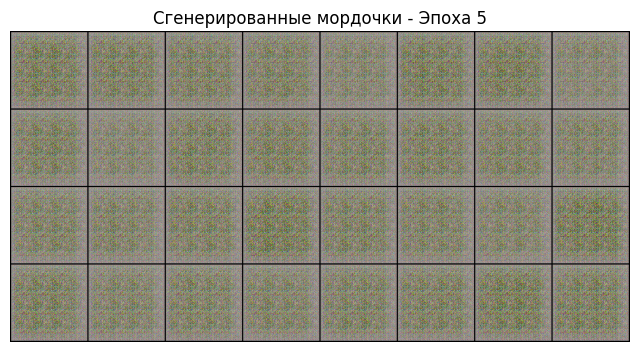

[6/50][0/51] Loss_D: 0.3332 Loss_G: 58.0256
[6/50][25/51] Loss_D: 0.3347 Loss_G: 56.2679
[6/50][50/51] Loss_D: 0.3311 Loss_G: 56.9532
[7/50][0/51] Loss_D: 0.3448 Loss_G: 56.6984
[7/50][25/51] Loss_D: 0.3355 Loss_G: 55.8219
[7/50][50/51] Loss_D: 0.3291 Loss_G: 52.4187
[8/50][0/51] Loss_D: 0.3287 Loss_G: 55.9674
[8/50][25/51] Loss_D: 0.3279 Loss_G: 54.6055
[8/50][50/51] Loss_D: 0.3366 Loss_G: 57.4195
[9/50][0/51] Loss_D: 0.3317 Loss_G: 56.1495
[9/50][25/51] Loss_D: 0.3283 Loss_G: 55.4971
[9/50][50/51] Loss_D: 0.3306 Loss_G: 54.6958
[10/50][0/51] Loss_D: 0.3312 Loss_G: 54.9132
[10/50][25/51] Loss_D: 0.3292 Loss_G: 54.7318
[10/50][50/51] Loss_D: 0.3369 Loss_G: 54.5993


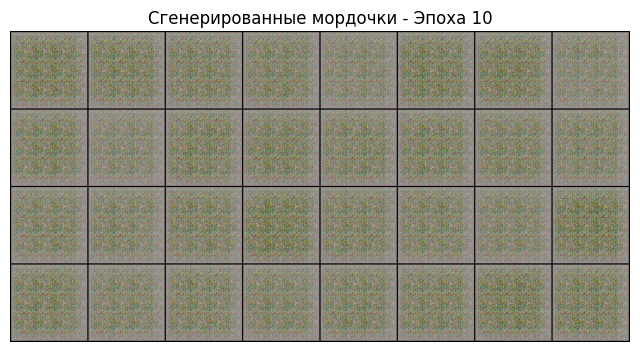

[11/50][0/51] Loss_D: 0.3299 Loss_G: 53.0613
[11/50][25/51] Loss_D: 0.3272 Loss_G: 54.7152
[11/50][50/51] Loss_D: 0.3301 Loss_G: 56.2970
[12/50][0/51] Loss_D: 0.3379 Loss_G: 53.1615
[12/50][25/51] Loss_D: 0.3316 Loss_G: 53.5592
[12/50][50/51] Loss_D: 0.3290 Loss_G: 54.5234
[13/50][0/51] Loss_D: 0.3280 Loss_G: 52.6826
[13/50][25/51] Loss_D: 0.3302 Loss_G: 52.6978
[13/50][50/51] Loss_D: 0.3289 Loss_G: 52.3802
[14/50][0/51] Loss_D: 0.3288 Loss_G: 52.5162
[14/50][25/51] Loss_D: 0.3262 Loss_G: 52.0393
[14/50][50/51] Loss_D: 0.3311 Loss_G: 50.8177
[15/50][0/51] Loss_D: 0.3294 Loss_G: 53.1654
[15/50][25/51] Loss_D: 0.3272 Loss_G: 51.7553
[15/50][50/51] Loss_D: 0.3292 Loss_G: 53.8680


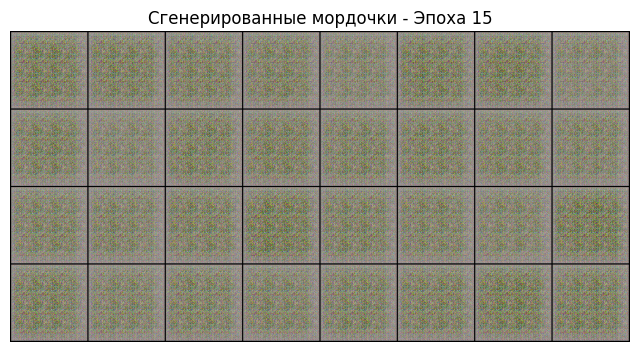

[16/50][0/51] Loss_D: 0.3283 Loss_G: 51.1356
[16/50][25/51] Loss_D: 0.3263 Loss_G: 51.8669
[16/50][50/51] Loss_D: 0.3778 Loss_G: 49.6950
[17/50][0/51] Loss_D: 0.4225 Loss_G: 49.7957
[17/50][25/51] Loss_D: 0.3312 Loss_G: 47.4445
[17/50][50/51] Loss_D: 0.3300 Loss_G: 48.6384
[18/50][0/51] Loss_D: 0.3333 Loss_G: 48.6590
[18/50][25/51] Loss_D: 0.3358 Loss_G: 46.6845
[18/50][50/51] Loss_D: 3.3988 Loss_G: 3.0438
[19/50][0/51] Loss_D: 2.4632 Loss_G: 2.7257
[19/50][25/51] Loss_D: 0.5961 Loss_G: 4.5025
[19/50][50/51] Loss_D: 0.8033 Loss_G: 3.3229
[20/50][0/51] Loss_D: 0.8811 Loss_G: 1.7454
[20/50][25/51] Loss_D: 1.1170 Loss_G: 3.1584
[20/50][50/51] Loss_D: 0.7597 Loss_G: 4.5989


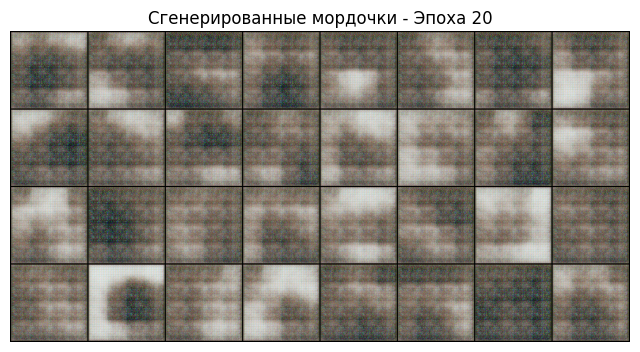

[21/50][0/51] Loss_D: 1.2768 Loss_G: 1.7741
[21/50][25/51] Loss_D: 0.5703 Loss_G: 4.3974
[21/50][50/51] Loss_D: 1.9070 Loss_G: 1.4416
[22/50][0/51] Loss_D: 1.3756 Loss_G: 5.4721
[22/50][25/51] Loss_D: 0.5087 Loss_G: 4.1918
[22/50][50/51] Loss_D: 0.7283 Loss_G: 3.1757
[23/50][0/51] Loss_D: 0.7129 Loss_G: 3.3982
[23/50][25/51] Loss_D: 0.7246 Loss_G: 4.2092
[23/50][50/51] Loss_D: 1.2396 Loss_G: 9.8276
[24/50][0/51] Loss_D: 2.2847 Loss_G: 5.5835
[24/50][25/51] Loss_D: 0.6732 Loss_G: 4.8186
[24/50][50/51] Loss_D: 0.8340 Loss_G: 1.3231
[25/50][0/51] Loss_D: 1.0211 Loss_G: 3.6680
[25/50][25/51] Loss_D: 0.6381 Loss_G: 4.5357
[25/50][50/51] Loss_D: 0.4738 Loss_G: 4.8648


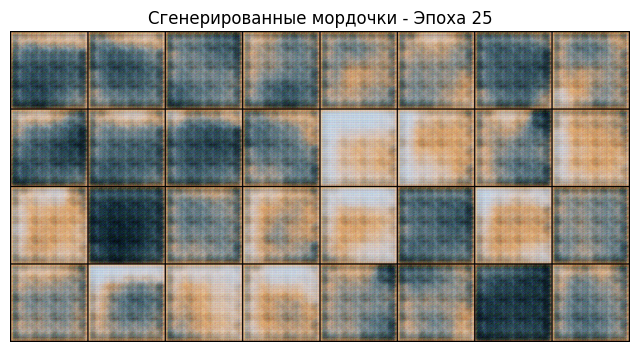

[26/50][0/51] Loss_D: 0.5565 Loss_G: 3.3490
[26/50][25/51] Loss_D: 1.7591 Loss_G: 2.7751
[26/50][50/51] Loss_D: 0.7124 Loss_G: 6.4926
[27/50][0/51] Loss_D: 0.4715 Loss_G: 4.0541
[27/50][25/51] Loss_D: 1.1345 Loss_G: 1.5317
[27/50][50/51] Loss_D: 1.2636 Loss_G: 0.8632
[28/50][0/51] Loss_D: 0.6728 Loss_G: 2.5905
[28/50][25/51] Loss_D: 1.0581 Loss_G: 2.4880
[28/50][50/51] Loss_D: 2.3360 Loss_G: 1.1864
[29/50][0/51] Loss_D: 2.3024 Loss_G: 5.0754
[29/50][25/51] Loss_D: 0.9085 Loss_G: 2.6613
[29/50][50/51] Loss_D: 0.6827 Loss_G: 4.9514
[30/50][0/51] Loss_D: 1.0095 Loss_G: 1.8906
[30/50][25/51] Loss_D: 0.7839 Loss_G: 2.4957
[30/50][50/51] Loss_D: 0.8016 Loss_G: 3.4651


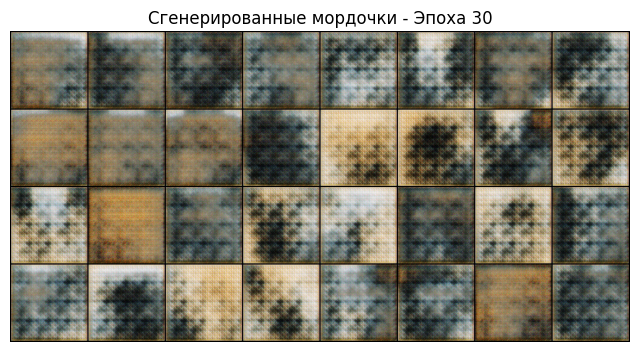

[31/50][0/51] Loss_D: 0.8480 Loss_G: 2.7484
[31/50][25/51] Loss_D: 1.0636 Loss_G: 4.9988
[31/50][50/51] Loss_D: 1.8270 Loss_G: 2.0092
[32/50][0/51] Loss_D: 1.7094 Loss_G: 5.8998
[32/50][25/51] Loss_D: 0.6158 Loss_G: 2.7853
[32/50][50/51] Loss_D: 0.5635 Loss_G: 4.1163
[33/50][0/51] Loss_D: 0.7910 Loss_G: 2.5892
[33/50][25/51] Loss_D: 0.8368 Loss_G: 3.4718
[33/50][50/51] Loss_D: 0.5037 Loss_G: 3.7957
[34/50][0/51] Loss_D: 0.6746 Loss_G: 3.0472
[34/50][25/51] Loss_D: 0.5740 Loss_G: 3.8573
[34/50][50/51] Loss_D: 1.9024 Loss_G: 1.1331
[35/50][0/51] Loss_D: 1.1880 Loss_G: 2.7084
[35/50][25/51] Loss_D: 0.8146 Loss_G: 3.2782
[35/50][50/51] Loss_D: 1.2783 Loss_G: 5.4307


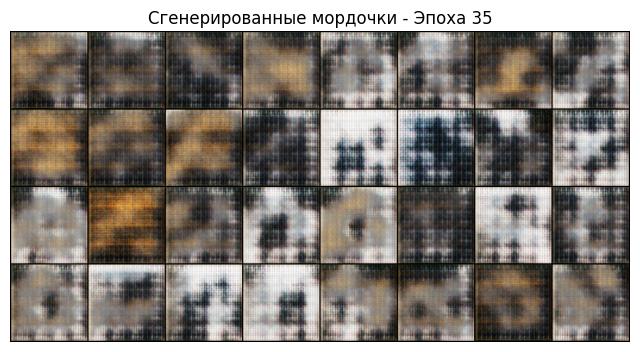

[36/50][0/51] Loss_D: 2.0368 Loss_G: 1.1085
[36/50][25/51] Loss_D: 0.8204 Loss_G: 2.9680
[36/50][50/51] Loss_D: 1.2322 Loss_G: 1.7451
[37/50][0/51] Loss_D: 1.5044 Loss_G: 5.4429
[37/50][25/51] Loss_D: 0.5867 Loss_G: 3.2851
[37/50][50/51] Loss_D: 0.8543 Loss_G: 2.9624
[38/50][0/51] Loss_D: 0.9842 Loss_G: 4.6102
[38/50][25/51] Loss_D: 0.7638 Loss_G: 3.9708
[38/50][50/51] Loss_D: 0.9134 Loss_G: 2.8157
[39/50][0/51] Loss_D: 0.8232 Loss_G: 3.8683
[39/50][25/51] Loss_D: 1.0038 Loss_G: 3.3026
[39/50][50/51] Loss_D: 0.6864 Loss_G: 5.8545
[40/50][0/51] Loss_D: 1.3561 Loss_G: 0.7650
[40/50][25/51] Loss_D: 1.0640 Loss_G: 2.5162
[40/50][50/51] Loss_D: 1.1263 Loss_G: 2.3544


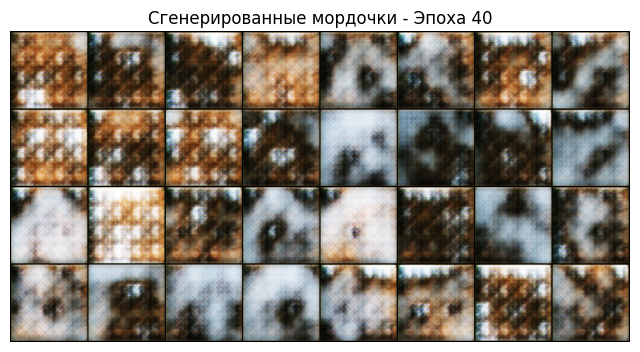

[41/50][0/51] Loss_D: 1.2089 Loss_G: 5.0123
[41/50][25/51] Loss_D: 0.8441 Loss_G: 2.6857
[41/50][50/51] Loss_D: 0.9228 Loss_G: 3.6344
[42/50][0/51] Loss_D: 0.9214 Loss_G: 1.7784
[42/50][25/51] Loss_D: 1.1072 Loss_G: 2.3485
[42/50][50/51] Loss_D: 1.0359 Loss_G: 3.8010
[43/50][0/51] Loss_D: 0.9762 Loss_G: 1.9900
[43/50][25/51] Loss_D: 1.3064 Loss_G: 2.0564
[43/50][50/51] Loss_D: 0.9231 Loss_G: 3.9446
[44/50][0/51] Loss_D: 0.6705 Loss_G: 3.1188
[44/50][25/51] Loss_D: 1.1155 Loss_G: 1.8546
[44/50][50/51] Loss_D: 0.6387 Loss_G: 2.6213
[45/50][0/51] Loss_D: 0.8648 Loss_G: 2.0621
[45/50][25/51] Loss_D: 0.8775 Loss_G: 2.3957
[45/50][50/51] Loss_D: 0.8939 Loss_G: 4.0878


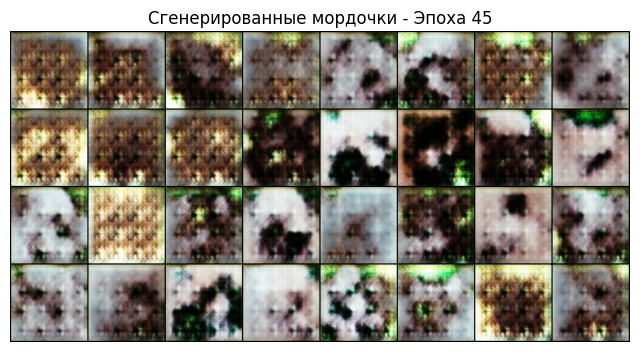

[46/50][0/51] Loss_D: 0.8704 Loss_G: 4.0059
[46/50][25/51] Loss_D: 0.7901 Loss_G: 3.9086
[46/50][50/51] Loss_D: 1.1445 Loss_G: 1.7920
[47/50][0/51] Loss_D: 1.6283 Loss_G: 5.8950
[47/50][25/51] Loss_D: 1.0784 Loss_G: 3.6744
[47/50][50/51] Loss_D: 1.0142 Loss_G: 2.1027
[48/50][0/51] Loss_D: 1.2726 Loss_G: 2.7429
[48/50][25/51] Loss_D: 0.8378 Loss_G: 2.2234
[48/50][50/51] Loss_D: 1.0572 Loss_G: 7.3367
[49/50][0/51] Loss_D: 0.9461 Loss_G: 3.3628
[49/50][25/51] Loss_D: 0.8338 Loss_G: 3.6863
[49/50][50/51] Loss_D: 1.1669 Loss_G: 2.8954
[50/50][0/51] Loss_D: 1.1928 Loss_G: 3.8460
[50/50][25/51] Loss_D: 0.9767 Loss_G: 2.4253
[50/50][50/51] Loss_D: 0.6470 Loss_G: 1.8171


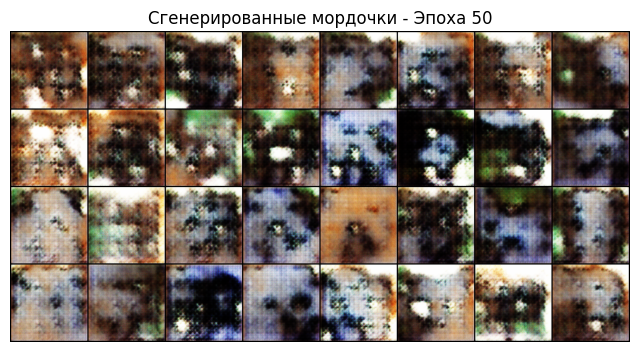

In [26]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(32, nz, 1, 1, device=device)

# Чуть-чуть уменьшили скорость обучения, чтобы обучение было стабильнее
lr = 0.00015
beta1 = 0.5
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

num_epochs = 50

print("Начинаем обучение GAN со сглаживанием меток (Label Smoothing)...")

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):
        # --- 1. Обучаем Дискриминатор ---
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)

        # МАГИЯ ЗДЕСЬ: Label Smoothing. Вместо 1.0 ставим 0.9 для реальных фото!
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)

        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0) # Фейки так и оставляем нулями

        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # --- 2. Обучаем Генератор ---
        netG.zero_grad()
        # Для генератора мы всё ещё хотим, чтобы D думал, что картинка идеальная (1.0)
        label.fill_(1.0)

        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        if i % 25 == 0:
            print(f'[{epoch+1}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

    if (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
        with torch.no_grad():
            fake_imgs = netG(fixed_noise).detach().cpu()

        plt.figure(figsize=(8,8))
        plt.axis("off")
        plt.title(f"Сгенерированные мордочки - Эпоха {epoch+1}")
        plt.imshow(np.transpose(vutils.make_grid(fake_imgs, padding=2, normalize=True).cpu(),(1,2,0)))
        plt.show()